# 02 – Fertility per municipality

**Purpose:** Turn SCB's total fertility rate per municipality 2000–2025 into an analysis-ready table with one row per municipality and year. The table has a municipality code, handled missing data and a detrended measure.

| | |
|---|---|
| **Source** | SCB, Statistikdatabasen: total fertility rate per municipality and sex |
| **Raw data** | `data/raw/FertilitetPerKommun.csv` |
| **Helper files** | `data/raw/befolkningstathet.csv` (only for municipality codes and population), `data/processed/fruktbarhet_riket.csv` (from `01`) |
| **Output** | `data/processed/fertilitet_kommun.csv`, `data/processed/exkluderade_kommuner.csv` |
| **Dependencies** | Run `01_Fruktbarhet_riket` first. `03_befolkningstathet` reads the list of excluded municipalities from here. |

### Decisions implemented

1. **Exclude municipalities with at least 50 % missing data** from all municipality-level analysis. They are reported in a separate file and are not counted as zero.
2. **Keep the other municipalities with `NaN` intact.** No zeros and no guessed values.
3. **Linearly interpolate only isolated gaps**, i.e. one missing year between two known years, and only in municipalities with little missing data. Every interpolated value is flagged.
4. **Knivsta is kept.** The series starts in 2003 because the municipality was formed then.
5. **Add flags** (`n_ar_med_data`, `har_bortfall`) instead of filtering silently. This makes it possible to run a robustness check with and without the small municipalities.
6. **Choose women** as the measure, since it is the standard measure. Men's series follows women's almost exactly.
7. **Detrend against the national rate:** `skillnad_mot_riket = fertility − national fertility the same year`.

## 1. Settings and parameters

The adjustable decisions are collected here. Changing a threshold here takes effect throughout the notebook.

- `KON`: which sex is used as the outcome measure.
- `GRANS_UTESLUT`: municipalities with at least this share of missing values are excluded.
- `GRANS_INTERPOLERA`: only municipalities with *less* missing data than this have their isolated gaps interpolated. Municipalities with a lot of missing data have such sparse data that a gap is no longer an exception. There the gaps are left empty.

The missing share is calculated on both sexes (26 years × 2 = 52 values per municipality), in the same way as in the decision document.

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# If it is run from the project root, we locate Assignment anyway.
BAS = Path.cwd()
if not (BAS / "data" / "raw").is_dir() and (BAS / "Assignment").is_dir():
    BAS = BAS / "Assignment"

RAW = BAS / "data" / "raw"
PROCESSED = BAS / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

assert RAW.is_dir(), "Cannot find data/raw. Open the notebook from the Assignment folder."

KON = "kvinnor"
GRANS_UTESLUT = 0.5
GRANS_INTERPOLERA = 0.25

## 2. Load raw data

The file is semicolon-separated and encoded in UTF-8 with BOM. Missing values appear as empty fields, which pandas automatically reads as `NaN`. Each row is one municipality, one sex and one year.

In [18]:
fert_ra = pd.read_csv(RAW / "FertilitetPerKommun.csv", sep=";", encoding="utf-8-sig")

display(fert_ra.head())
print("Shape:", fert_ra.shape)
print(fert_ra.dtypes)

,region,kön,tabellinnehåll,år,Värde
0,Upplands Väsby,män,Antal,2000,1.43
1,Upplands Väsby,män,Antal,2001,1.52
2,Upplands Väsby,män,Antal,2002,1.51
3,Upplands Väsby,män,Antal,2003,1.64
4,Upplands Väsby,män,Antal,2004,1.56


Shape: (15080, 5)
region             object
kön                object
tabellinnehåll     object
år                  int64
Värde             float64
dtype: object


## 3. Check the structure

We expect 290 municipalities × 2 sexes × 26 years = 15,080 rows and no duplicates.

The column `tabellinnehåll` only has the value `Antal` ("count"). The column carries no information and is dropped in step 6.

In [19]:
assert list(fert_ra.columns) == ["region", "kön", "tabellinnehåll", "år", "Värde"]
assert fert_ra["region"].nunique() == 290
assert set(fert_ra["kön"]) == {"män", "kvinnor"}
assert fert_ra["år"].min() == 2000 and fert_ra["år"].max() == 2025
assert len(fert_ra) == 290 * 2 * 26
assert not fert_ra.duplicated(["region", "kön", "år"]).any()
assert fert_ra["tabellinnehåll"].unique().tolist() == ["Antal"]
assert pd.api.types.is_float_dtype(fert_ra["Värde"])

print("Total missing values:", fert_ra["Värde"].isna().sum(), "of", len(fert_ra),
      f"({fert_ra['Värde'].isna().mean():.1%})")
print("Value range:", fert_ra["Värde"].min(), "–", fert_ra["Värde"].max())

Total missing values: 414 of 15080 (2.7%)
Value range: 0.8 – 3.15


## 4. Attach the municipality code

The fertility file only has municipality names. A name is a fragile key, so we fetch the four-digit municipality code from the density file. It also comes from SCB and has both code and name. After that, all tables can be joined on code instead of name.

The population from the density file is kept temporarily. It is used in the next step to show that the missing data is related to municipality size.

In [20]:
tathet_ra = pd.read_csv(RAW / "befolkningstathet.csv", encoding="utf-8-sig", dtype={"Kommunkod": str})

nyckel = tathet_ra[["Kommunkod", "Kommun"]].drop_duplicates()
nyckel["namnnyckel"] = nyckel["Kommun"].str.strip().str.casefold()
assert nyckel["Kommunkod"].str.fullmatch(r"\d{4}").all()
assert not nyckel.duplicated("namnnyckel").any()
assert not nyckel.duplicated("Kommunkod").any()

fert = fert_ra.assign(namnnyckel=fert_ra["region"].str.strip().str.casefold())
fert = fert.merge(nyckel, on="namnnyckel", how="left", validate="many_to_one")
assert fert["Kommunkod"].notna().all(), "Some municipality name has no code in the density file."

folkmangd_2025 = (
    tathet_ra.loc[tathet_ra["År"] == 2025, ["Kommunkod", "Folkmängd"]]
    .set_index("Kommunkod")["Folkmängd"]
)
print("All", fert["Kommunkod"].nunique(), "municipalities received a municipality code.")

All 290 municipalities received a municipality code.


## 5. Missing data per municipality

Missing data is small overall (2.7 %), but it is **concentrated** in a few municipalities, and it is **not random**. Municipalities with missing data are considerably smaller than the others. This is because SCB does not report the rate when the underlying numbers are below 30 births per year.

The table shows all municipalities that have any missing data, sorted by share.

In [21]:
bortfall = (
    fert.groupby(["Kommunkod", "Kommun"])["Värde"]
    .agg(n_varden="size", n_saknas=lambda s: s.isna().sum())
    .reset_index()
)
bortfall["bortfall_andel"] = bortfall["n_saknas"] / bortfall["n_varden"]
bortfall["folkmangd_2025"] = bortfall["Kommunkod"].map(folkmangd_2025).round().astype(int)

med_bortfall = bortfall.loc[bortfall["n_saknas"] > 0].sort_values("bortfall_andel", ascending=False)
display(med_bortfall.assign(bortfall_procent=(med_bortfall["bortfall_andel"] * 100).round(0))
        .drop(columns="bortfall_andel"))

utan = bortfall.loc[bortfall["n_saknas"] == 0, "folkmangd_2025"].median()
med = med_bortfall["folkmangd_2025"].median()
print(f"Municipalities with missing data: {len(med_bortfall)} of {len(bortfall)}")
print(f"Median population 2025 – with missing data: {med:,.0f}, without missing data: {utan:,.0f}")

,Kommunkod,Kommun,n_varden,n_saknas,folkmangd_2025,bortfall_procent
262,2403,Bjurholm,52,52,2327,100.0
269,2425,Dorotea,52,50,2241,96.0
268,2422,Sorsele,52,46,2362,88.0
279,2513,Överkalix,52,44,3183,85.0
277,2506,Arjeplog,52,40,2570,77.0
272,2463,Åsele,52,40,2683,77.0
188,1762,Munkfors,52,27,3637,52.0
266,2418,Malå,52,22,2902,42.0
281,2518,Övertorneå,52,20,3995,38.0
44,0512,Ydre,52,16,3619,31.0


Municipalities with missing data: 22 of 290
Median population 2025 – with missing data: 3,903, without missing data: 17,522


## 6. Exclude municipalities with at least 50 % missing data

Municipalities where at least half of the values are missing have no time series to analyse. Dorotea, for example, has only 2 of 52 values. What remains is noise from a very small population. These municipalities are removed from all municipality-level analysis.

They are not removed silently. The list is saved in `exkluderade_kommuner.csv` with the number of values and a justification, so that the selection can be reported in the methods section. `03_befolkningstathet` reads the same list, so that all files exclude the same municipalities.

In [22]:
exkluderade = bortfall.loc[bortfall["bortfall_andel"] >= GRANS_UTESLUT].copy()
exkluderade["n_ar_med_data"] = exkluderade["n_varden"] - exkluderade["n_saknas"]
exkluderade["motivering"] = (
    f"At least {GRANS_UTESLUT:.0%} of the values are missing (both sexes 2000–2025). "
    "Too little data for a time series. Excluded from municipality-level analysis."
)
exkluderade = exkluderade[["Kommunkod", "Kommun", "n_ar_med_data", "n_varden", "bortfall_andel", "motivering"]]
exkluderade = exkluderade.sort_values("bortfall_andel", ascending=False)

exkluderade.to_csv(PROCESSED / "exkluderade_kommuner.csv", index=False, encoding="utf-8-sig")
display(exkluderade.drop(columns="motivering").round(2))

fert = fert.loc[~fert["Kommunkod"].isin(exkluderade["Kommunkod"])]
print(f"Excluded {len(exkluderade)} municipalities. Remaining: {fert['Kommunkod'].nunique()} municipalities.")

,Kommunkod,Kommun,n_ar_med_data,n_varden,bortfall_andel
262,2403,Bjurholm,0,52,1.00
269,2425,Dorotea,2,52,0.96
268,2422,Sorsele,6,52,0.88
279,2513,Överkalix,8,52,0.85
272,2463,Åsele,12,52,0.77
277,2506,Arjeplog,12,52,0.77
188,1762,Munkfors,25,52,0.52


Excluded 7 municipalities. Remaining: 283 municipalities.


## 7. Choose sex and tidy columns

We keep women's fertility, which is the standard measure. Men's series follows women's almost exactly, so using both would produce meaningless rules such as *"high fertility men → high fertility women"*. Men's values remain in the raw data file if they are needed later.

Columns are renamed to short ASCII names (`ar`, `fruktsamhet`). Empty or constant columns are dropped (`kön`, `tabellinnehåll`, `namnnyckel`). The municipality name is taken from the density file, so that the spelling is the same in all processed files.

In [23]:
fert = (
    fert.loc[fert["kön"] == KON, ["Kommunkod", "Kommun", "år", "Värde"]]
    .rename(columns={"år": "ar", "Värde": "fruktsamhet"})
    .sort_values(["Kommunkod", "ar"])
    .reset_index(drop=True)
)

assert len(fert) == fert["Kommunkod"].nunique() * 26
display(fert.head())
print("Shape:", fert.shape, "| missing values:", fert["fruktsamhet"].isna().sum())

,Kommunkod,Kommun,ar,fruktsamhet
0,0114,Upplands Väsby,2000,1.54
1,0114,Upplands Väsby,2001,1.59
2,0114,Upplands Väsby,2002,1.65
3,0114,Upplands Väsby,2003,1.81
4,0114,Upplands Väsby,2004,1.69


Shape: (7358, 4) | missing values: 56


## 8. Knivsta – the series starts in 2003

Knivsta was split off from Uppsala municipality and became a municipality of its own in **2003**. The values for 2000–2002 are therefore missing for a structural reason, not because of a small population. We check that exactly those years are missing. The values are left as `NaN`, so the series effectively starts in 2003.

Knivsta's gaps are at the start of the series. They therefore cannot be interpolated in the next step, since there is no known value before them.

In [24]:
knivsta = fert.loc[fert["Kommun"] == "Knivsta"]
saknade_ar = knivsta.loc[knivsta["fruktsamhet"].isna(), "ar"].tolist()

assert saknade_ar == [2000, 2001, 2002], saknade_ar
forsta_ar = knivsta.loc[knivsta["fruktsamhet"].notna(), "ar"].min()
assert forsta_ar == 2003
print("Knivsta is missing values for:", saknade_ar, "– the series starts", forsta_ar)

Knivsta is missing values for: [2000, 2001, 2002] – the series starts 2003


## 9. Data coverage flags

Two columns make missing data visible in the analysis, instead of letting it disappear silently:

- `n_ar_med_data`: number of years out of 26 with an *observed* value for the municipality. Counted before interpolation.
- `har_bortfall`: `True` if the municipality is missing at least one year.


In [25]:
fert["n_ar_med_data"] = fert.groupby("Kommunkod")["fruktsamhet"].transform("count").astype(int)
fert["har_bortfall"] = fert["n_ar_med_data"] < 26

print("Municipalities with missing data:", fert.loc[fert["har_bortfall"], "Kommunkod"].nunique())
print("Municipalities without missing data:", fert.loc[~fert["har_bortfall"], "Kommunkod"].nunique())

Municipalities with missing data: 13
Municipalities without missing data: 270


## 10. Interpolate isolated gaps

A missing year between two known years can be filled with linear interpolation. For a single year, this is the mean of the year before and the year after. It is not a guess, since the value lies between two measured points.

Two conditions decide what is interpolated:

1. The gap is exactly one year long, and both the year before and the year after have values. Longer gaps and gaps at the start or end of the series are left as `NaN`.
2. The municipality's total missing share is below `GRANS_INTERPOLERA` In municipalities with a lot of missing data a gap is no longer an exception. There, interpolation would invent more than it fills in.

Every filled value gets `interpolerad = True`, so that it can be excluded in a robustness check.

In [26]:
foregaende = fert.groupby("Kommunkod")["fruktsamhet"].shift(1)
nasta = fert.groupby("Kommunkod")["fruktsamhet"].shift(-1)
bortfall_andel = fert["Kommunkod"].map(bortfall.set_index("Kommunkod")["bortfall_andel"])

ensamt_hal = fert["fruktsamhet"].isna() & foregaende.notna() & nasta.notna()
far_interpoleras = ensamt_hal & (bortfall_andel < GRANS_INTERPOLERA)

fert["interpolerad"] = far_interpoleras
fert.loc[far_interpoleras, "fruktsamhet"] = (foregaende + nasta)[far_interpoleras] / 2

visning = fert.loc[far_interpoleras, ["Kommun", "ar", "fruktsamhet"]].assign(
    ar_fore=foregaende[far_interpoleras], ar_efter=nasta[far_interpoleras])
display(visning.round(3))

ej = fert.loc[ensamt_hal & ~far_interpoleras, "Kommun"].value_counts()
print(f"Interpolated: {far_interpoleras.sum()} values in {fert.loc[far_interpoleras, 'Kommun'].nunique()} municipalities.")
print(f"Isolated gaps left empty because of high missing share: {ensamt_hal.sum() - far_interpoleras.sum()}",
      ej.to_dict())
print("Total remaining as NaN:", fert["fruktsamhet"].isna().sum())

,Kommun,ar,fruktsamhet,ar_fore,ar_efter
3741,Dals-Ed,2023,1.685,1.55,1.82
3967,Gullspång,2015,2.230,2.15,2.31
4847,Storfors,2011,2.535,2.55,2.52
4851,Storfors,2015,2.155,2.47,1.84
4858,Storfors,2022,1.915,1.98,1.85
5197,Laxå,2023,1.780,1.78,1.78
5290,Ljusnarsberg,2012,2.155,2.19,2.12
5471,Skinnskatteberg,2011,2.155,2.13,2.18
5481,Skinnskatteberg,2021,1.840,1.81,1.87
6576,Ragunda,2024,1.690,1.98,1.40


Interpolated: 11 values in 8 municipalities.
Isolated gaps left empty because of high missing share: 12 {'Övertorneå': 5, 'Ydre': 4, 'Malå': 3}
Total remaining as NaN: 45


## 11. Detrend against the national rate

Fertility has a clear national trend, it rose until around 2010 and has fallen since then. If the absolute values are divided into classes over the whole period, "high fertility" becomes almost the same thing as "the years around 2010". ARM would then just find the calendar.

The solution is to compare each municipality with the national rate the same year:

`skillnad_mot_riket = fruktsamhet − national fertility`

A positive value means more children per woman than the national rate the same year. The national trend disappears, and the difference between municipalities remains.

The reference is SCB's official national rate (from `01`), not an average of the municipalities. An unweighted municipal average gives tiny Bjurholm the same weight as Stockholm and ends up systematically too high, as the table below shows. With that baseline, most municipalities would incorrectly end up below the national rate.

In [27]:
riket = pd.read_csv(PROCESSED / "fruktbarhet_riket.csv", encoding="utf-8-sig")
assert riket["ar"].tolist() == list(range(2000, 2026)), "Run 01_Fruktbarhet_riket first."

jamforelse = riket[["ar", "fruktsamhet_riket_kvinnor"]].assign(
    medel_av_kommuner=riket["ar"].map(fert.groupby("ar")["fruktsamhet"].mean()))
jamforelse["skillnad"] = jamforelse["medel_av_kommuner"] - jamforelse["fruktsamhet_riket_kvinnor"]
display(jamforelse.loc[jamforelse["ar"].isin([2000, 2010, 2020, 2025])].round(2))

fert = fert.merge(
    riket[["ar", "fruktsamhet_riket_kvinnor"]].rename(columns={"fruktsamhet_riket_kvinnor": "fruktsamhet_riket"}),
    on="ar", how="left", validate="many_to_one",
)
assert fert["fruktsamhet_riket"].notna().all()
fert["skillnad_mot_riket"] = fert["fruktsamhet"] - fert["fruktsamhet_riket"]

,ar,fruktsamhet_riket_kvinnor,medel_av_kommuner,skillnad
0,2000,1.54,1.69,0.15
10,2010,1.98,2.11,0.13
20,2020,1.66,1.84,0.18
25,2025,1.42,1.57,0.15


### Check: did the trend disappear?

We compare the municipalities' median per year before and after detrending. Before, the median clearly moves with the national trend. After, it should be almost flat. The spread between years (the standard deviation of the yearly medians) should therefore become much smaller.

That the median after detrending lies around +0.12 rather than 0 is expected. The national rate is dominated by the populous municipalities, and the big cities have lower fertility than the average municipality. The typical municipality is therefore slightly above the national rate. What matters is that the level is stable over time, not that it is zero.

In [28]:
arsmedian = fert.groupby("ar")[["fruktsamhet", "skillnad_mot_riket"]].median()

display(arsmedian.loc[[2000, 2005, 2010, 2015, 2020, 2025]].round(2))
print("Spread between yearly medians (std):")
print(f"  fruktsamhet (raw):  {arsmedian['fruktsamhet'].std():.3f}")
print(f"  skillnad_mot_riket: {arsmedian['skillnad_mot_riket'].std():.3f}")

,fruktsamhet,skillnad_mot_riket
ar,,
2000,1.66,0.12
2005,1.91,0.14
2010,2.10,0.12
2015,1.97,0.12
2020,1.81,0.15
2025,1.54,0.12


Spread between yearly medians (std):
  fruktsamhet (raw):  0.159
  skillnad_mot_riket: 0.020


## 12. Final check

Before the file is saved we check that:

- every municipality has exactly 26 rows (2000–2025) and the key `Kommunkod` + `ar` is unique
- no excluded municipalities remain
- missing values in `skillnad_mot_riket` occur exactly where fertility is missing, and nowhere else.

In [29]:
kolumner = ["Kommunkod", "Kommun", "ar", "fruktsamhet", "interpolerad", "fruktsamhet_riket",
            "skillnad_mot_riket", "n_ar_med_data", "har_bortfall"]
fert = fert[kolumner]

assert not fert.duplicated(["Kommunkod", "ar"]).any()
assert (fert.groupby("Kommunkod").size() == 26).all()
assert not fert["Kommunkod"].isin(exkluderade["Kommunkod"]).any()
assert fert["skillnad_mot_riket"].isna().equals(fert["fruktsamhet"].isna())

print(f"{fert['Kommunkod'].nunique()} municipalities × 26 years = {len(fert)} rows")
print(f"Missing values remaining: {fert['fruktsamhet'].isna().sum()} ({fert['fruktsamhet'].isna().mean():.1%})")
print(f"Interpolated values: {fert['interpolerad'].sum()}")
display(fert.head())

283 municipalities × 26 years = 7358 rows
Missing values remaining: 45 (0.6%)
Interpolated values: 11


,Kommunkod,Kommun,ar,fruktsamhet,interpolerad,fruktsamhet_riket,skillnad_mot_riket,n_ar_med_data,har_bortfall
0,0114,Upplands Väsby,2000,1.54,False,1.54,0.00,26,False
1,0114,Upplands Väsby,2001,1.59,False,1.57,0.02,26,False
2,0114,Upplands Väsby,2002,1.65,False,1.65,0.00,26,False
3,0114,Upplands Väsby,2003,1.81,False,1.71,0.10,26,False
4,0114,Upplands Väsby,2004,1.69,False,1.75,-0.06,26,False


## 13. Save

Two files are saved:

- `fertilitet_kommun.csv` – the analysis dataset, one row per municipality and year.
- `exkluderade_kommuner.csv` – already saved in step 6 and used by `03_befolkningstathet`.

The municipality code is saved as text with a leading zero. Therefore read the file with `dtype={"Kommunkod": str}`.

In [30]:
utfil = PROCESSED / "fertilitet_kommun.csv"
fert.to_csv(utfil, index=False, encoding="utf-8-sig")

print(f"Saved {len(fert)} rows to {utfil.relative_to(BAS)}")
print(f"Saved {len(exkluderade)} excluded municipalities to data/processed/exkluderade_kommuner.csv")

Saved 7358 rows to data\processed\fertilitet_kommun.csv
Saved 7 excluded municipalities to data/processed/exkluderade_kommuner.csv


## 14. Plot

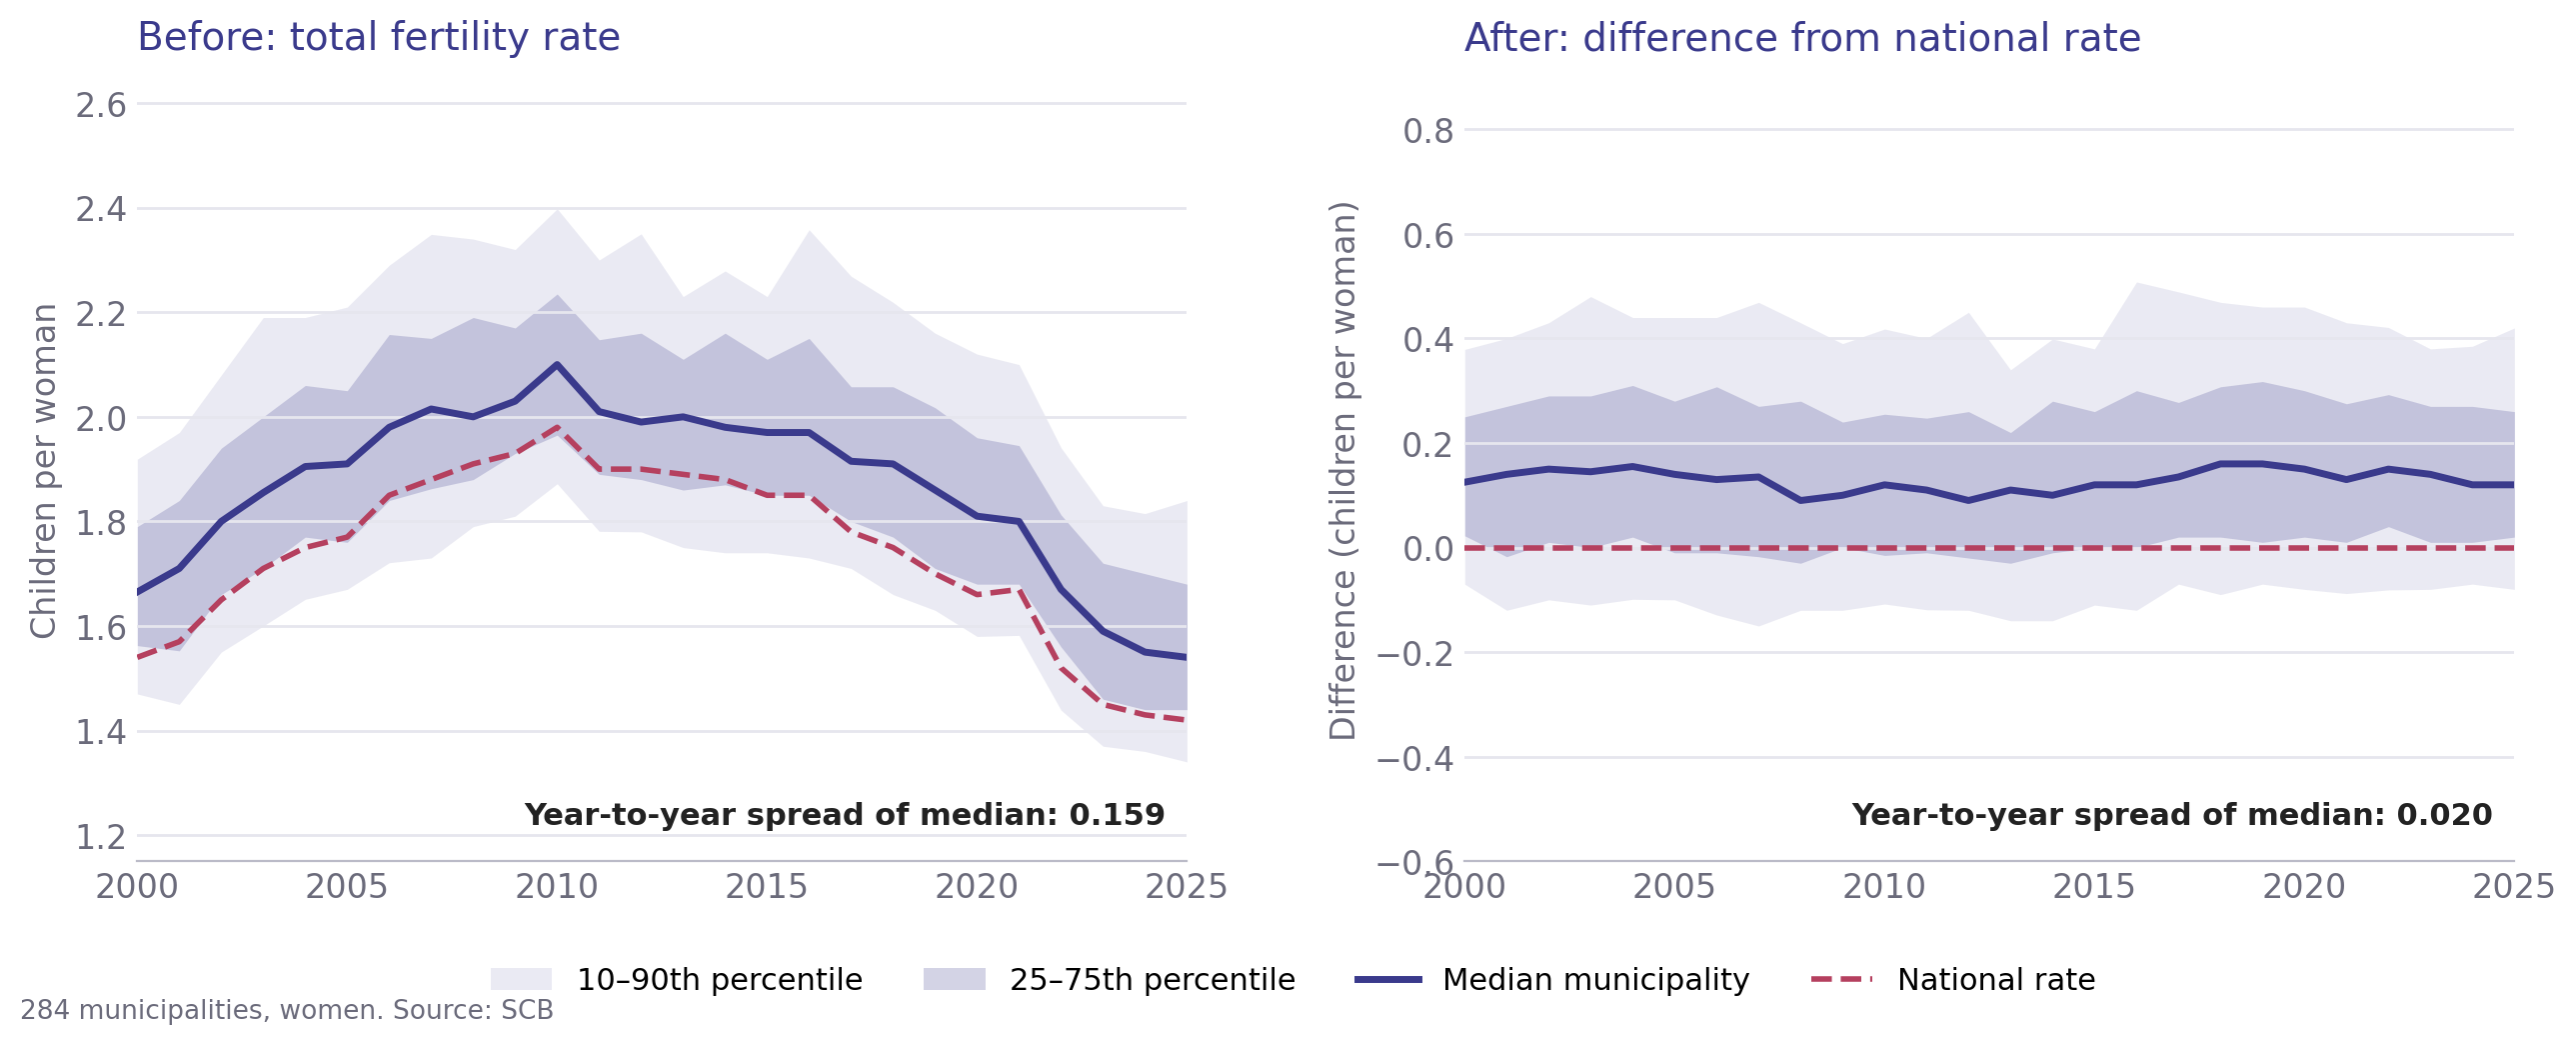

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# The result from 02_FertilitetPerKommun
fert = fert.copy()

NAVY, PINK, MUTED, GRID = "#3A3A8C", "#B5405F", "#6B6B7B", "#E6E6EE"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})


def percentiler(kolumn):
    g = fert.groupby("ar")[kolumn]
    return pd.DataFrame({"p10": g.quantile(0.10), "p25": g.quantile(0.25), "median": g.median(),
                         "p75": g.quantile(0.75), "p90": g.quantile(0.90)})


fore, efter = percentiler("fruktsamhet"), percentiler("skillnad_mot_riket")
riket = fert.groupby("ar")["fruktsamhet_riket"].first()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), dpi=200)
SPANN = 1.5  # same height on both y-axes, so that the flatness can be compared

for ax, d, titel, ylabel, ymin in [
    (ax1, fore, "Before: total fertility rate", "Children per woman", 1.15),
    (ax2, efter, "After: difference from national rate", "Difference (children per woman)", -0.6),
]:
    ax.fill_between(d.index, d["p10"], d["p90"], color=NAVY, alpha=0.10, lw=0, label="10–90th percentile")
    ax.fill_between(d.index, d["p25"], d["p75"], color=NAVY, alpha=0.22, lw=0, label="25–75th percentile")
    ax.plot(d.index, d["median"], color=NAVY, lw=2.5, label="Median municipality")
    ax.set_ylim(ymin, ymin + SPANN)
    ax.set_xlim(2000, 2025)
    ax.set_xticks(range(2000, 2026, 5))
    ax.set_title(titel, loc="left", fontsize=14, color=NAVY, pad=10)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.grid(axis="y", color=GRID, lw=1)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#BBBBC8")
    ax.tick_params(colors=MUTED, length=0)

ax1.plot(riket.index, riket.values, color=PINK, lw=2, ls="--", label="National rate")
ax2.axhline(0, color=PINK, lw=2, ls="--", label="National rate (= 0)")

sd_fore = fore["median"].std()
sd_efter = efter["median"].std()
for ax, sd in [(ax1, sd_fore), (ax2, sd_efter)]:
    ax.text(0.98, 0.04, f"Year-to-year spread of median: {sd:.3f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=11, color="#222", fontweight="bold")

h, l = ax1.get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.0))
fig.text(0.01, 0.005, "284 municipalities, women. Source: SCB", fontsize=9.5, color=MUTED)
fig.tight_layout(rect=(0, 0.08, 1, 1), w_pad=3)
fig.savefig("detrending_02.png", facecolor="white")